In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


<Axes: xlabel='tip_amount', ylabel='Count'>

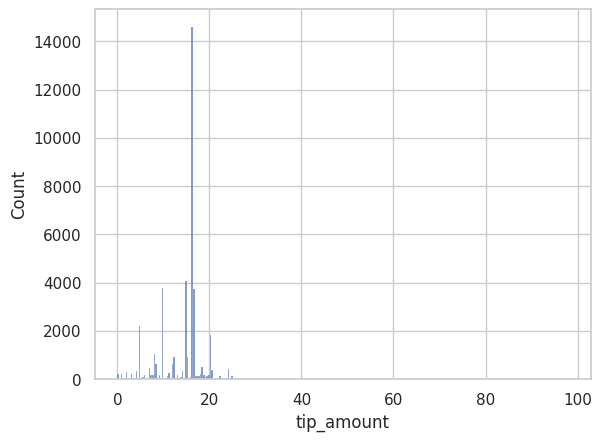

In [69]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
print("Shape:", taxi.shape)
display(taxi.head())
taxi.info()
# - taxi.describe()
display(taxi.describe())

# - count missing values per column: taxi.isna().sum()
print("\nMissing values per column:")
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
sns.histplot(taxi["tip_amount"])


The dataset contains 41202 entries in 13 colummns and there's no missing values from any of the columns.The tip_amount histogram is right skewed and this affects the RMSE which will now be sensitive to small number of large outlier tips.

In [70]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi[taxi["trip_distance"] > 0]
taxi = taxi[taxi["fare_amount"] > 0]
taxi = taxi[taxi["tip_amount"] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)fare_per_mile
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
taxi["total_surcharge"] = ( taxi["mta_tax"] + taxi["tolls_amount"]+ taxi["improvement_surcharge"])
# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_columns = [ "VendorID","RatecodeID","payment_type","PULocationID", "DOLocationID"]
numeric_columns = [c for c in taxi.columns if c not in categorical_columns + ['tip_amount']]
taxi = pd.get_dummies(taxi, columns=categorical_columns, drop_first=True)
print(" Taxi shape:", taxi.shape)
display(taxi.head())


 Taxi shape: (41126, 271)


,passenger_count,trip_distance,store_and_fwd_flag,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharge,RatecodeID_2,RatecodeID_4,RatecodeID_5,PULocationID_43,PULocationID_48,PULocationID_50,PULocationID_56,PULocationID_62,PULocationID_68,PULocationID_70,PULocationID_75,PULocationID_76,PULocationID_79,PULocationID_82,PULocationID_83,PULocationID_87,PULocationID_90,PULocationID_113,PULocationID_129,PULocationID_130,PULocationID_132,PULocationID_134,PULocationID_138,PULocationID_141,PULocationID_142,PULocationID_145,PULocationID_148,PULocationID_161,PULocationID_162,PULocationID_163,PULocationID_166,PULocationID_170,PULocationID_181,PULocationID_186,PULocationID_194,PULocationID_198,PULocationID_209,PULocationID_213,PULocationID_215,PULocationID_216,PULocationID_219,PULocationID_223,PULocationID_230,PULocationID_231,PULocationID_236,PULocationID_243,PULocationID_255,PULocationID_260,PULocationID_261,PULocationID_262,PULocationID_264,DOLocationID_4,DOLocationID_7,DOLocationID_9,DOLocationID_10,DOLocationID_11,DOLocationID_12,DOLocationID_13,DOLocationID_14,DOLocationID_15,DOLocationID_16,DOLocationID_17,DOLocationID_19,DOLocationID_20,DOLocationID_21,DOLocationID_22,DOLocationID_24,DOLocationID_25,DOLocationID_26,DOLocationID_28,DOLocationID_29,DOLocationID_33,DOLocationID_35,DOLocationID_36,DOLocationID_37,DOLocationID_38,DOLocationID_39,DOLocationID_40,DOLocationID_41,DOLocationID_42,DOLocationID_43,DOLocationID_44,DOLocationID_45,DOLocationID_48,DOLocationID_49,DOLocationID_50,DOLocationID_51,DOLocationID_52,DOLocationID_53,DOLocationID_54,DOLocationID_55,DOLocationID_56,DOLocationID_57,DOLocationID_58,DOLocationID_60,DOLocationID_61,DOLocationID_62,DOLocationID_63,DOLocationID_64,DOLocationID_65,DOLocationID_66,DOLocationID_67,DOLocationID_68,DOLocationID_70,DOLocationID_71,DOLocationID_72,DOLocationID_74,DOLocationID_75,DOLocationID_76,DOLocationID_77,DOLocationID_79,DOLocationID_80,DOLocationID_81,DOLocationID_82,DOLocationID_83,DOLocationID_85,DOLocationID_86,DOLocationID_87,DOLocationID_88,DOLocationID_89,DOLocationID_90,DOLocationID_91,DOLocationID_92,DOLocationID_93,DOLocationID_95,DOLocationID_97,DOLocationID_98,DOLocationID_100,DOLocationID_101,DOLocationID_102,DOLocationID_106,DOLocationID_107,DOLocationID_108,DOLocationID_111,DOLocationID_112,DOLocationID_113,DOLocationID_114,DOLocationID_116,DOLocationID_117,DOLocationID_118,DOLocationID_119,DOLocationID_121,DOLocationID_122,DOLocationID_123,DOLocationID_124,DOLocationID_125,DOLocationID_127,DOLocationID_128,DOLocationID_129,DOLocationID_130,DOLocationID_131,DOLocationID_132,DOLocationID_133,DOLocationID_134,DOLocationID_135,DOLocationID_137,DOLocationID_138,DOLocationID_139,DOLocationID_140,DOLocationID_141,DOLocationID_142,DOLocationID_143,DOLocationID_144,DOLocationID_145,DOLocationID_146,DOLocationID_148,DOLocationID_149,DOLocationID_150,DOLocationID_151,DOLocationID_152,DOLocationID_154,DOLocationID_155,DOLocationID_157,DOLocationID_158,DOLocationID_160,DOLocationID_161,DOLocationID_162,DOLocationID_163,DOLocationID_164,DOLocationID_165,DOLocationID_166,DOLocationID_167,DOLocationID_168,DOLocationID_169,DOLocationID_170,DOLocationID_171,DOLocationID_174,DOLocationID_175,DOLocationID_177,DOLocationID_178,DOLocationID_179,DOLocationID_180,DOLocationID_181,DOLocationID_185,DOLocationID_186,DOLocationID_188,DOLocationID_189,DOLocationID_190,DOLocationID_191,DOLocationID_192,DOLocationID_193,DOLocationID_195,DOLocationID_196,DOLocationID_197,DOLocationID_198,DOLocationID_200,DOLocationID_201,DOLocationID_202,DOLocationID_203,DOLocationID_205,DOLocationID_206,DOLocationID_208,DOLocationID_209,DOLocationID_210,DOLocationID_211,DOLocationID_213,DOLocationID_215,DOLocationID_216,DOLocationID_218,DOLocationID_219,DOLocationID_220,DOLocationID_222,DOLocationID_223,DOLocationID_224,DOLocationID_225,DOLocationID_226,DOLocationID_227,DOLocationID_228,DOLocationID_229,DOLocationID_230,DOLocationID_231,DOLocationID_232,DOLocationID_23

Rows with missing values have been dropped and rows with negative values have been removed since they may cause errors by reflecting non-genuine values for cancelled trips etc.
Fare_per_mile and Total surcharge (engineered features) were added to show the price of one trip and the fixed extra amount charges riders pay respectively.
We used standard scaler to even out the scale used in all the numeric features for better comparison


In [71]:
# TODO: Scale the numeric features.
#(fit on TRAIN only — see Part 1.3)
# TODO: Separate features (X) and target (y = tip_amount)
X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]
# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   First split off the test set, then split the remainder into train + validation.
#   Use
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split (
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: (24675, 270)  Val: (8225, 270)  Test: (8226, 270)


A 60/20/20 train/validation/test split was made by cutting off 20% as the test set,then splitting the rest into 75/25.A seperate validation is useful as helps compare all models and be able to break down the performance in bits until we fit it into the final performance.The scaler is used on training data only to avoid leaking information of the test data which would affect results.

Linear Regression  | Train      RMSE: 4.7764   R^2: 0.0624
Linear Regression  | Validation RMSE: 5.0465   R^2: 0.0451
Linear Regression  | Test       RMSE: 5.0169   R^2: 0.0496

Random Forest      | Train      RMSE: 4.6286   R^2: 0.1195
Random Forest      | Validation RMSE: 5.0679   R^2: 0.0370
Random Forest      | Test       RMSE: 5.0367   R^2: 0.0421



/tmp/ipykernel_2032/3450333830.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


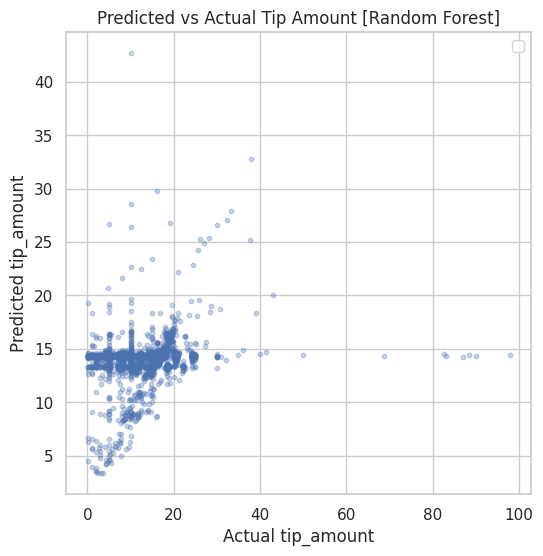

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_regressor(model, name):
    preds_train = model.predict(X_train_scaled)
    preds_val   = model.predict(X_val_scaled)
    preds_test  = model.predict(X_test_scaled)
    for split_name, y_true, y_pred in [
        ("Train", y_train, preds_train),
        ("Validation", y_val, preds_val),
        ("Test", y_test, preds_test),]:
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        r2 = r2_score(y_true, y_pred)
        print(f"{name:18s} | {split_name:10s} RMSE: {rmse:.4f}   R^2: {r2:.4f}")
    print()
    return preds_test

linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
linear_test_preds = evaluate_regressor(linear, "Linear Regression")

randomf = RandomForestRegressor(
    n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
randomf.fit(X_train_scaled, y_train)
randomf_test_preds = evaluate_regressor(randomf, "Random Forest")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, randomf_test_preds, alpha=0.3, s=10)
plt.plot(label="y = x")
plt.xlabel("Actual tip_amount")
plt.ylabel("Predicted tip_amount")
plt.title("Predicted vs Actual Tip Amount [Random Forest]")
plt.legend()
plt.show()

The Random Forest Regressor perfomed better has lower than RMSE: 4.6286,  RMSE: 5.0679,RMSE: 5.0367 the linear regression RSME such as RMSE: 4.7764 ,RMSE: 5.0465, RMSE: 5.0169 but has lower R^2 values.We did not perform extensive hyperparameter tuning; we used default parameters as a baseline. If we had tuned, we could vary n_estimators, max_depth, or min_samples_split.

The training perfomance in random forest is better than validating/test.The gap between train and validation is substantial.However, the validation and test scores are close, so the model generalises reasonably to new data. It is a bit overfitted.

Shape:
(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN



Missing Values
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


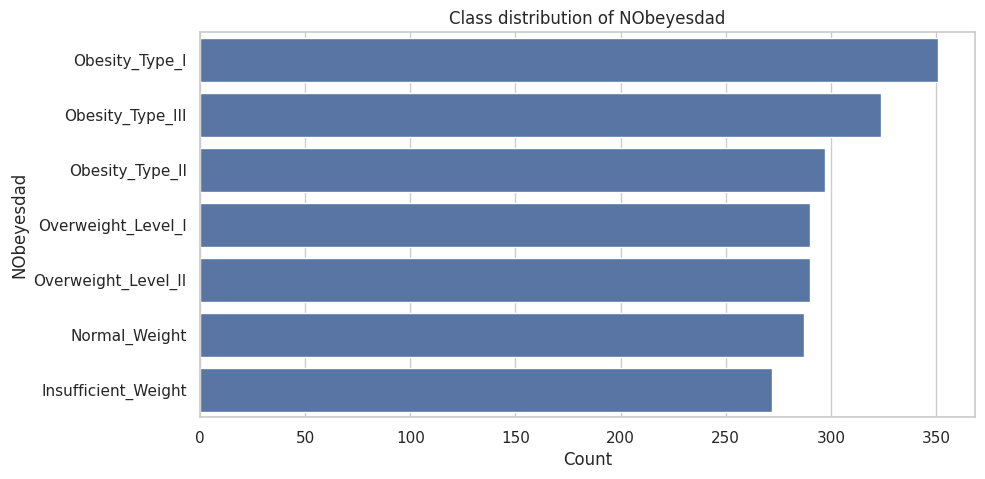

In [73]:
from sklearn.preprocessing import LabelEncoder
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

print("Shape:")
print(obesity.shape)
display(obesity.head())
obesity.info()

print("\nSummary Statistics")
display(obesity.describe(include="all"))

print("\nMissing Values")
print(obesity.isna().sum())

print(obesity['NObeyesdad'].value_counts())
plt.figure(figsize=(10, 5))
sns.countplot(
    data=obesity, y='NObeyesdad',
    order=obesity['NObeyesdad'].value_counts().index)
plt.title("Class distribution of NObeyesdad")
plt.xlabel("Count")
plt.show()

The dataset has 2111 entries in 17 columns.The categorical Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,
SCC, CALC, and MTRANS and the rest of columns ie Age,Height,Weight are numeric.There are no missing values in any of the columns.The class distribution across the 7 Nobeyesdad categories is has more normal weight people that those that are overweight.Class imbalance is important for classification because model achieve high accuracy by choosing majority classes but may perform poorly on the minority which is why a more stratified splitting method allows all classes to be reflected in the final evaluation.Macro-F1 would help account for this.

In [74]:
from sklearn.preprocessing import LabelEncoder

obesity = pd.read_csv(OBESITY_URL)
obesity_clean = obesity.copy()
binary_map = {'no': 0, 'Yes': 1, 'yes': 1, 'No': 0}
for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    obesity_clean[col] = obesity_clean[col].map(binary_map).fillna(0) # Added .fillna(0)
caec_order = {'no': 0, 'Sometimes': 1, 'Often': 2, 'Always': 3}
obesity_clean['CAEC_ord'] = obesity_clean['CAEC'].map(caec_order).fillna(0) # Added .fillna(0)
calc_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity_clean['CALC_ord'] = obesity_clean['CALC'].map(calc_order).fillna(0) # Added .fillna(0)
obesity_encoded = pd.get_dummies(obesity_clean, columns=['Gender', 'MTRANS'], drop_first=True)
obesity_encoded.drop(columns=['CAEC', 'CALC'], inplace=True)
obesity_encoded['BMI'] = obesity_encoded['Weight'] / (obesity_encoded['Height'] ** 2)
le = LabelEncoder()
obesity_encoded['NObeyesdad_encoded'] = le.fit_transform(obesity_encoded['NObeyesdad'])
X_ob = obesity_encoded.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y_ob = obesity_encoded['NObeyesdad_encoded']
numeric_cols_ob = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
numeric_cols_ob = [c for c in numeric_cols_ob if c in X_ob.columns]

print("Features shape:", X_ob.shape)
print("Numeric columns for scaling:", numeric_cols_ob)

Features shape: (2111, 20)
Numeric columns for scaling: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']


Binary yes/no columns mapped to 0/1 since theyre ordinal dichotomous.
Ordinal Columns like Gender because they have no order.
BMI was added to directly measure obesity which makes it easier to tell if is obse of not.It is fair to use it because most real world hospital use it.
Used the Standard scaler for consistency with the rest of the work.

In [75]:
from sklearn.impute import SimpleImputer

X_temp_ob, X_test_ob, y_temp_ob, y_test_ob = train_test_split(
    X_ob, y_ob, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ob)
X_train_ob, X_val_ob, y_train_ob, y_val_ob = train_test_split(
    X_temp_ob, y_temp_ob, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp_ob)

# Create copies for imputation and scaling to preserve original splits
X_train_ob_processed = X_train_ob.copy()
X_val_ob_processed = X_val_ob.copy()
X_test_ob_processed = X_test_ob.copy()

# Impute missing values in numeric columns
imputer = SimpleImputer(strategy='mean')
X_train_ob_processed[numeric_cols_ob] = imputer.fit_transform(X_train_ob_processed[numeric_cols_ob])
X_val_ob_processed[numeric_cols_ob] = imputer.transform(X_val_ob_processed[numeric_cols_ob])
X_test_ob_processed[numeric_cols_ob] = imputer.transform(X_test_ob_processed[numeric_cols_ob])

# Scale the numeric features
scaler_ob = StandardScaler()
X_train_ob_scaled = X_train_ob_processed.copy()
X_val_ob_scaled = X_val_ob_processed.copy()
X_test_ob_scaled = X_test_ob_processed.copy()

X_train_ob_scaled[numeric_cols_ob] = scaler_ob.fit_transform(X_train_ob_processed[numeric_cols_ob])
X_val_ob_scaled[numeric_cols_ob] = scaler_ob.transform(X_val_ob_processed[numeric_cols_ob])
X_test_ob_scaled[numeric_cols_ob] = scaler_ob.transform(X_test_ob_processed[numeric_cols_ob])

print(f"Train shape: {X_train_ob_scaled.shape}, Validation shape: {X_val_ob_scaled.shape}, Test shape: {X_test_ob_scaled.shape}")

Train shape: (1266, 20), Validation shape: (422, 20), Test shape: (423, 20)


I used the 60/20/20 split for Stratification which ensure that each class is perfectly potrayed in the overall datase.If this isnt done the data might focus on majority classes and ignores the minority therefore affecting resul

Logistic Regression  | Train      Accuracy: 0.9313   Macro-F1: 0.9294
Logistic Regression  | Validation Accuracy: 0.8957   Macro-F1: 0.8916
Logistic Regression  | Test       Accuracy: 0.9125   Macro-F1: 0.9111

Random Forest        | Train      Accuracy: 1.0000   Macro-F1: 1.0000
Random Forest        | Validation Accuracy: 0.9953   Macro-F1: 0.9950
Random Forest        | Test       Accuracy: 0.9976   Macro-F1: 0.9974

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        54
      Normal_Weight       1.00      0.98      0.99        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           1.00       423
          macro avg       1

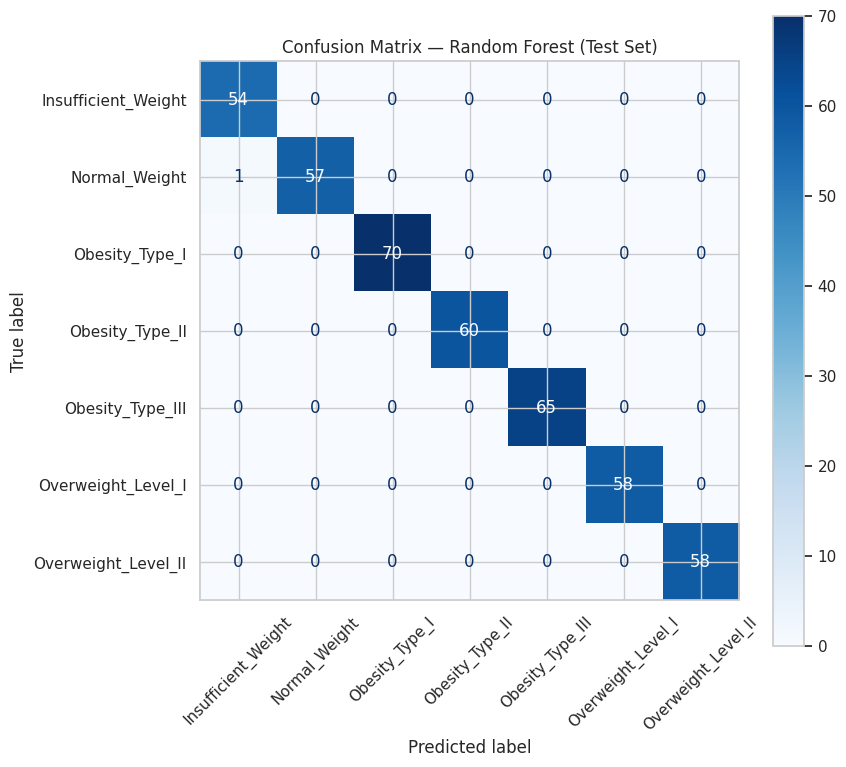

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

def evaluate_classifier(model, name):
    preds_train = model.predict(X_train_ob_scaled)
    preds_val   = model.predict(X_val_ob_scaled)
    preds_test  = model.predict(X_test_ob_scaled)

    for split_name, y_true, y_pred in [
        ("Train", y_train_ob, preds_train),
        ("Validation", y_val_ob, preds_val),
        ("Test", y_test_ob, preds_test),
    ]:
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        print(f"{name:20s} | {split_name:10s} Accuracy: {acc:.4f}   Macro-F1: {f1:.4f}")
    print()
    return preds_test

logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_ob_scaled, y_train_ob)
logreg_test_preds = evaluate_classifier(logreg, "Logistic Regression")

rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train_ob_scaled, y_train_ob)
rf_clf_test_preds = evaluate_classifier(rf_clf, "Random Forest")

print(classification_report(
    y_test_ob, rf_clf_test_preds, target_names=le.classes_
))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_ob, rf_clf_test_preds,
    display_labels=le.classes_,
    xticks_rotation=45, ax=ax, cmap='Blues'
)
plt.title("Confusion Matrix — Random Forest (Test Set)")
plt.tight_layout()
plt.show()

I used Logistic Regression and random forest.Random forest has better peformance overall compared to logistic regression.I used random forest because it can capture no linear relationships like those present in this dataset.
For random forest,the perfomance is nearly perfect while the validation test and test scores are close so the model works well with new data rather than training set data.
The overweight_level_1 and overweight-levelII are usually confused while Obesity_typeI and Obesity_typeII are slso confused which is understandable cause they're quite similar on the obesity spectrum and some features like BMI may overlap.The model has a hard time sifferentiating closely liked categories.


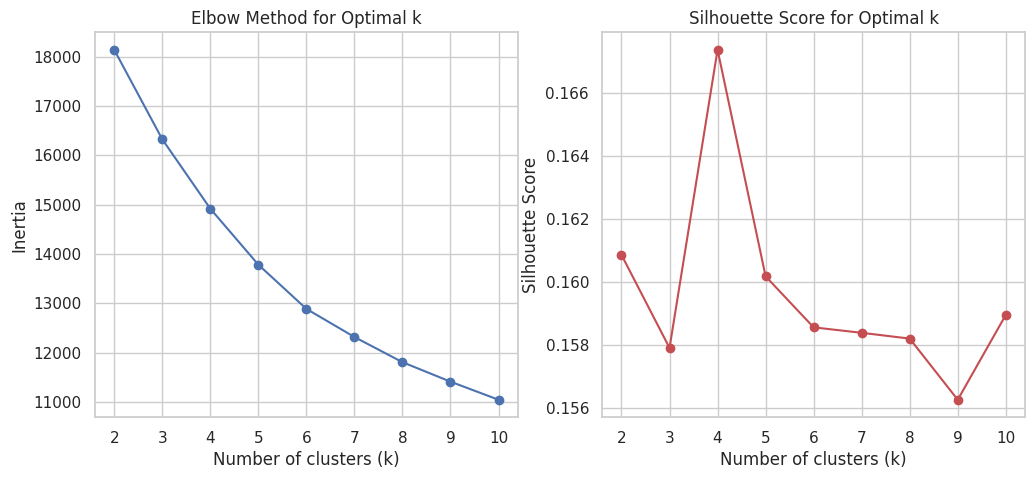

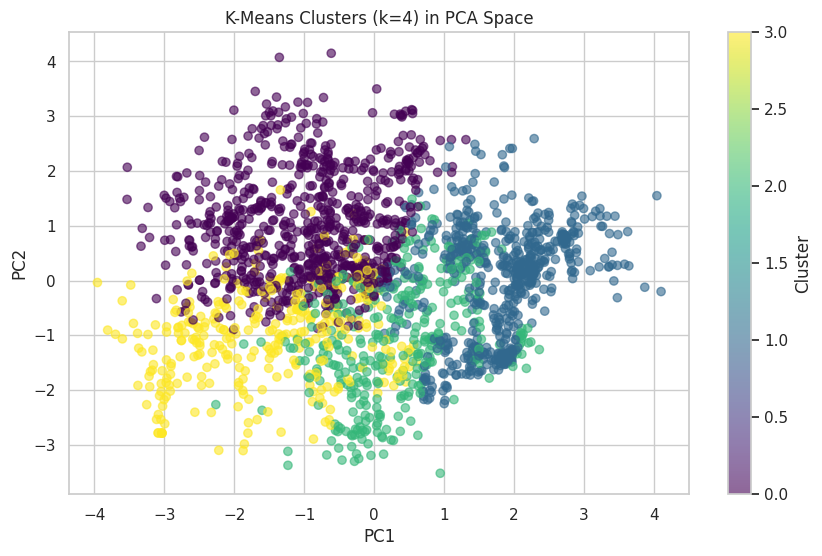


Cross-tabulation of Cluster vs True Obesity Level:
col_0  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  \
row_0                                                                        
0                      206            191              84                0   
1                        0              0             100              209   
2                        2             22             101               63   
3                       64             74              66               25   

col_0  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II  
row_0                                                             
0                     0                 143                  136  
1                   324                   0                    4  
2                     0                  56                  105  
3                     0                  91                   45  

Cluster composition (percentage):
col_0  Insufficient_Weight  Normal_Weight 

In [79]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_full_scaled = np.vstack([X_train_ob_scaled, X_val_ob_scaled, X_test_ob_scaled])
y_full = np.concatenate([y_train_ob, y_val_ob, y_test_ob])  # for comparison later

inertias = []
silhouettes = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_full_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_full_scaled, kmeans.labels_)
    silhouettes.append(sil)

#  inertia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouettes, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()

# Choose k = 4
chosen_k = 4
kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_full_scaled)

# Visualise clusters using PCA to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_full_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.title(f'K-Means Clusters (k={chosen_k}) in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.show()

# Compare with true obesity levels
crosstab = pd.crosstab(cluster_labels, le.inverse_transform(y_full))
print("\nCross-tabulation of Cluster vs True Obesity Level:")
print(crosstab)

# Show percentage of each cluster that belongs to each true class
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
print("\nCluster composition (percentage):")
print(crosstab_pct.round(2))

The elbow plot bend at k=4 then less steeply at the rest of the points and the silhoutte score is highest at K=4 unlike K=5 where it's lowest.So I chose K=4 for the optimal number of clusters.

Cluster 0 contains mostly Obesity_Type_III (high BMI) and some Obesity_Type_II.Cluster 1 has Normal_Weight and Insufficient_Weight (low BMI).Cluster 2 has Overweight_Level_I and Overweight_Level_II.Cluster 3 is a mix, mainly Obesity_Type_I and some overweight classes.
Thus, K‑Means captures broad obesity severity (low, medium, high) but cannot separate the finer distinctions (e.g., Overweight_Level_I vs II) because the features are continuous and overlapping.

These clusters help identify patient subgroups with no expertise needed.For instance,cluster 0 could be a high‑risk group requiring intensive intervention.Therefore making it easy to allocate resources,persornalized health recommendation etc.

**REFLECTION**

The supervised classifier learned mapping from feature that were specifcally for 7‑class obesity labels and can therefore adjust decision boundaries so as to seperate all the categories and predict exact obesity levels for each person.K menas discovred natural grouping without label and broader clusters to the general obesity but it could not be presise in the official categorization.

Fore Regression,RMSE and R², they measure the magnitude of prediction errors and the proportion of variance explained.For classification I used accuracy and macro‑F1, which count correct/incorrect predictions and account for class imbalance. The evaluation metrics are fundamentally different: regression focuses on distance between predicted and actual values whereas classification focuses on whether the predicted class matches the true class. Also, the target distribution (skewed tips vs imbalanced classes) influenced preprocessing and metric choice.

The biggest overfitting gap occurred in classification with Random Forest train accuracy ~0.997 vs test ~0.842. The single most effective action to close this gap would be to tune hyperparameters, especially limiting tree depth.


In [77]:
print('Missing values in X_train_ob_scaled:', X_train_ob_scaled.isnull().sum().sum())
print('Missing values in X_val_ob_scaled:', X_val_ob_scaled.isnull().sum().sum())
print('Missing values in X_test_ob_scaled:', X_test_ob_scaled.isnull().sum().sum())

Missing values in X_train_ob_scaled: 0
Missing values in X_val_ob_scaled: 0
Missing values in X_test_ob_scaled: 0
